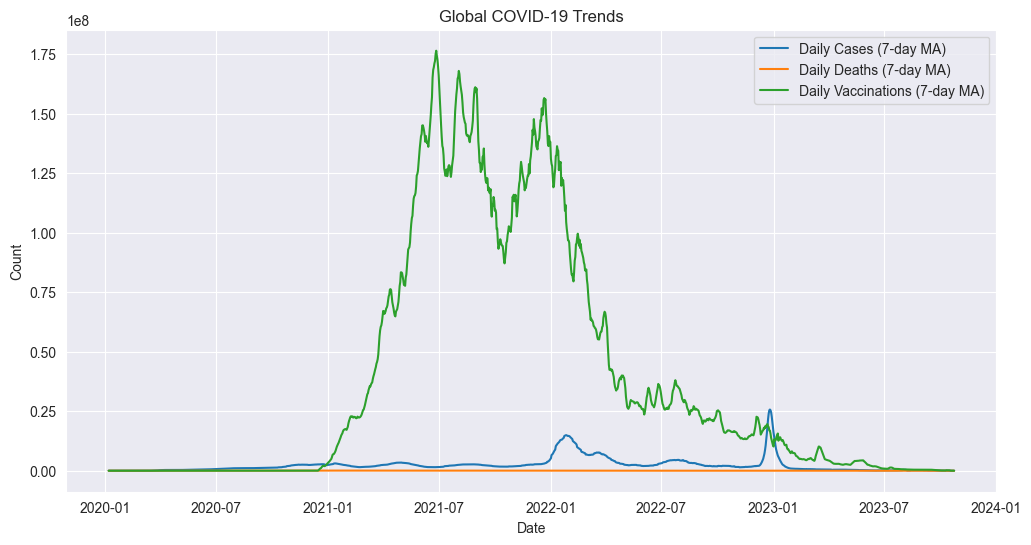

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/owid_covid_cleaned.csv")
df['date'] = pd.to_datetime(df['date'])

# گروه‌بندی کل جهان
world = df.groupby('date')[['new_cases','new_deaths','new_vaccinations']].sum().reset_index()

# میانگین متحرک 7 روزه
world['new_cases_ma'] = world['new_cases'].rolling(7).mean()
world['new_deaths_ma'] = world['new_deaths'].rolling(7).mean()
world['new_vaccinations_ma'] = world['new_vaccinations'].rolling(7).mean()

# رسم نمودار
plt.figure(figsize=(12,6))
plt.plot(world['date'], world['new_cases_ma'], label='Daily Cases (7-day MA)')
plt.plot(world['date'], world['new_deaths_ma'], label='Daily Deaths (7-day MA)')
plt.plot(world['date'], world['new_vaccinations_ma'], label='Daily Vaccinations (7-day MA)')
plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Global COVID-19 Trends')
plt.legend()
plt.show()
